# Latent State Discovery: Unsupervised Clustering Analysis

## EmoPairCompete Dataset - Discovering Emotional States through Biosignal Features

**Research Questions:**
- Can we discover latent emotional states through unsupervised clustering of biosignal features?
- How well do the discovered clusters align with known experimental conditions (resting, puzzling, recovery)?
- Which clustering method (K-Means, GMM, etc.) provides the best separation and interpretability?

**Methodology:**
This analysis explores multiple clustering approaches to identify natural groupings in the EmoPairCompete dataset and evaluates their correspondence with the experimental phases (pre-puzzle, puzzle, post-puzzle).

## Section 1: Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.metrics import (silhouette_score, silhouette_samples, davies_bouldin_score, 
                             calinski_harabasz_score, adjusted_rand_score, normalized_mutual_info_score)
from sklearn.decomposition import PCA
from scipy.spatial.distance import pdist, squareform
from scipy.cluster.hierarchy import dendrogram, linkage
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

# Configure visualization
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
print("Libraries imported successfully!")

Libraries imported successfully!


## Section 2: Load and Explore the Data

In [2]:
# Load the HR data
data_path = "Data/HR_data.csv"
df = pd.read_csv(data_path)

print("Dataset Shape:", df.shape)
print("\nColumn Names:")
print(df.columns.tolist())
print("\nFirst few rows:")
print(df.head())
print("\nData Types:")
print(df.dtypes)
print("\nMissing Values:")
print(df.isnull().sum())
print("\nBasic Statistics:")
print(df.describe())

Dataset Shape: (312, 68)

Column Names:
['Unnamed: 0', 'HR_TD_Mean', 'HR_TD_Median', 'HR_TD_std', 'HR_TD_Min', 'HR_TD_Max', 'HR_TD_AUC', 'HR_TD_Kurtosis', 'HR_TD_Skew', 'HR_TD_Slope_min', 'HR_TD_Slope_max', 'HR_TD_Slope_mean', 'HR_TD_Slope', 'TEMP_TD_Mean', 'TEMP_TD_Median', 'TEMP_TD_std', 'TEMP_TD_Min', 'TEMP_TD_Max', 'TEMP_TD_AUC', 'TEMP_TD_Kurtosis', 'TEMP_TD_Skew', 'TEMP_TD_Slope_min', 'TEMP_TD_Slope_max', 'TEMP_TD_Slope_mean', 'TEMP_TD_Slope', 'EDA_TD_P_Mean', 'EDA_TD_P_Median', 'EDA_TD_P_std', 'EDA_TD_P_Min', 'EDA_TD_P_Max', 'EDA_TD_P_AUC', 'EDA_TD_P_Kurtosis', 'EDA_TD_P_Skew', 'EDA_TD_P_Slope_min', 'EDA_TD_P_Slope_max', 'EDA_TD_P_Slope_mean', 'EDA_TD_P_Slope', 'EDA_TD_T_Mean', 'EDA_TD_T_Median', 'EDA_TD_T_std', 'EDA_TD_T_Min', 'EDA_TD_T_Max', 'EDA_TD_T_AUC', 'EDA_TD_T_Kurtosis', 'EDA_TD_T_Skew', 'EDA_TD_T_Slope_min', 'EDA_TD_T_Slope_max', 'EDA_TD_T_Slope_mean', 'EDA_TD_T_Slope', 'EDA_TD_P_Peaks', 'EDA_TD_P_RT', 'EDA_TD_P_ReT', 'Round', 'Phase', 'Individual', 'Puzzler', 'Frustrat

In [3]:
# Identify numeric columns for clustering
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(f"Number of numeric features: {len(numeric_cols)}")
print(f"Features for clustering: {numeric_cols[:10]}...")  # Show first 10

# Check if phase information is available
print("\nChecking for phase/condition information:")
print(df.columns[df.columns.str.contains('phase', case=False, na=False)].tolist())

Number of numeric features: 65
Features for clustering: ['Unnamed: 0', 'HR_TD_Mean', 'HR_TD_Median', 'HR_TD_std', 'HR_TD_Min', 'HR_TD_Max', 'HR_TD_AUC', 'HR_TD_Kurtosis', 'HR_TD_Skew', 'HR_TD_Slope_min']...

Checking for phase/condition information:
['Phase']


## Section 3: Data Preprocessing and Normalization

In [4]:
# Extract numeric features for clustering
X = df[numeric_cols].copy()

# Handle missing values - remove rows with missing values
print(f"Rows before removing NaN: {X.shape[0]}")
X = X.dropna()
print(f"Rows after removing NaN: {X.shape[0]}")

# Remove outliers using IQR method (optional - can be commented out if too aggressive)
def remove_outliers_iqr(data, threshold=1.5):
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - threshold * IQR
    upper_bound = Q3 + threshold * IQR
    mask = ((data >= lower_bound) & (data <= upper_bound)).all(axis=1)
    return data[mask]

# Apply outlier removal (keeping data relatively intact for noisy biosignals)
X_clean = remove_outliers_iqr(X, threshold=3.0)
print(f"Rows after removing outliers: {X_clean.shape[0]}")

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_clean)
X_scaled = pd.DataFrame(X_scaled, columns=numeric_cols)

print(f"\nScaled data shape: {X_scaled.shape}")
print(f"Mean of scaled features: {X_scaled.mean().mean():.6f}")
print(f"Std of scaled features: {X_scaled.std().mean():.6f}")

Rows before removing NaN: 312
Rows after removing NaN: 307
Rows after removing outliers: 134

Scaled data shape: (134, 65)
Mean of scaled features: 0.000000
Std of scaled features: 0.957425


## Section 4: Clustering Analysis with K-Means

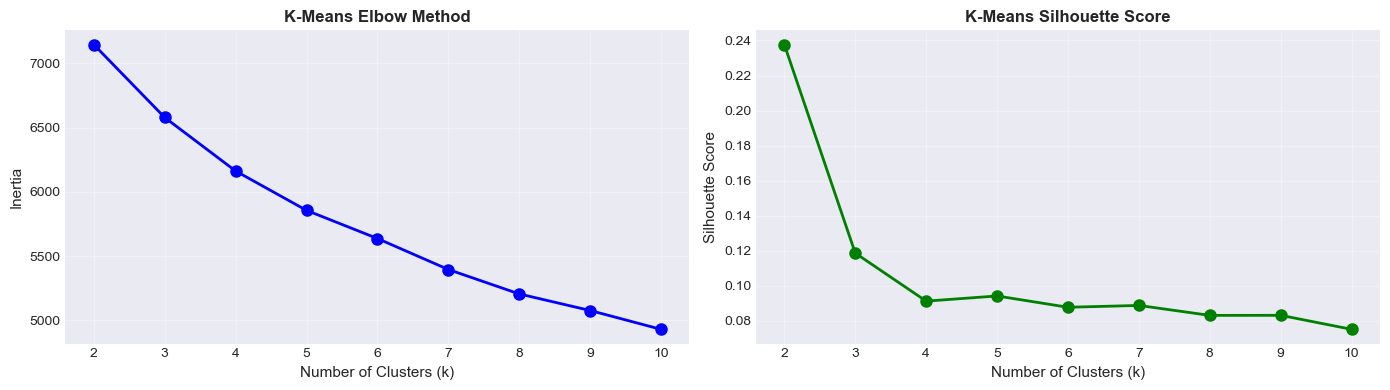

Optimal k (by silhouette score): 2
Silhouette scores for each k: {2: np.float64(0.238), 3: np.float64(0.119), 4: np.float64(0.091), 5: np.float64(0.094), 6: np.float64(0.088), 7: np.float64(0.089), 8: np.float64(0.083), 9: np.float64(0.083), 10: np.float64(0.075)}


In [5]:
# K-Means Elbow Method and Silhouette Analysis
inertias = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, kmeans.labels_))

# Plot elbow method and silhouette scores
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Elbow plot
axes[0].plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Number of Clusters (k)', fontsize=11)
axes[0].set_ylabel('Inertia', fontsize=11)
axes[0].set_title('K-Means Elbow Method', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Silhouette scores
axes[1].plot(K_range, silhouette_scores, 'go-', linewidth=2, markersize=8)
axes[1].set_xlabel('Number of Clusters (k)', fontsize=11)
axes[1].set_ylabel('Silhouette Score', fontsize=11)
axes[1].set_title('K-Means Silhouette Score', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Find optimal k
optimal_k_silhouette = K_range[np.argmax(silhouette_scores)]
print(f"Optimal k (by silhouette score): {optimal_k_silhouette}")
print(f"Silhouette scores for each k: {dict(zip(K_range, np.round(silhouette_scores, 3)))}")

In [6]:
# Train final K-Means model with optimal k (using 3 for alignment with 3 phases)
optimal_k = 3  # Based on experimental phases: pre-puzzle, puzzle, post-puzzle
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
kmeans_labels = kmeans_final.fit_predict(X_scaled)

print(f"K-Means clustering with k={optimal_k}")
print(f"Cluster sizes: {np.bincount(kmeans_labels)}")
print(f"Silhouette Score: {silhouette_score(X_scaled, kmeans_labels):.4f}")

K-Means clustering with k=3
Cluster sizes: [31 22 81]
Silhouette Score: 0.1186


## Section 5: Clustering Analysis with Gaussian Mixture Models

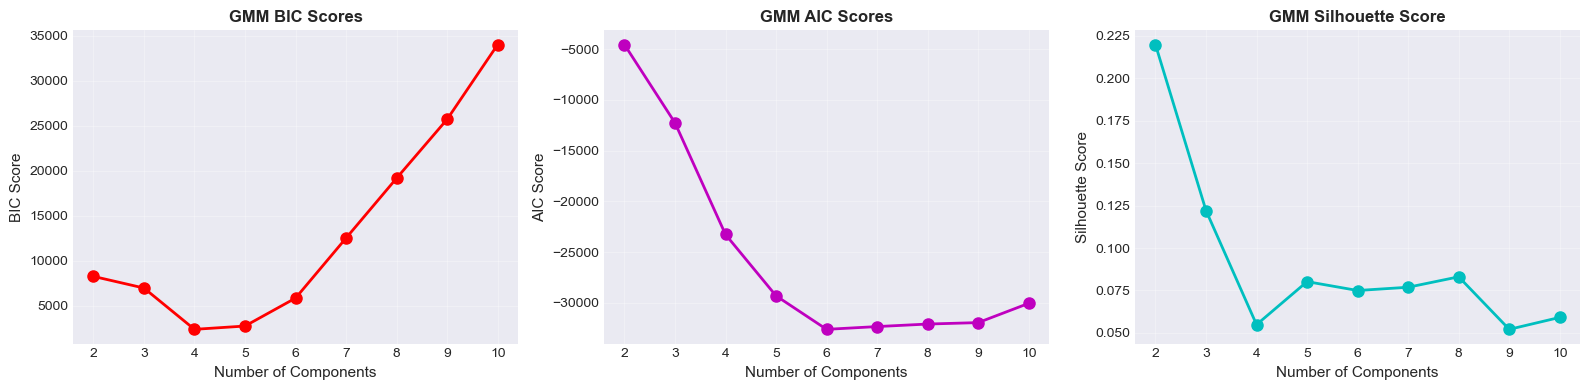

Optimal components (by BIC): 4
Optimal components (by AIC): 6
BIC scores: {2: np.float64(8249.91), 3: np.float64(6954.27), 4: np.float64(2360.92), 5: np.float64(2728.76), 6: np.float64(5834.22), 7: np.float64(12514.41), 8: np.float64(19170.1), 9: np.float64(25719.68), 10: np.float64(34024.37)}
AIC scores: {2: np.float64(-4561.44), 3: np.float64(-12264.21), 4: np.float64(-23264.67), 5: np.float64(-29303.96), 6: np.float64(-32605.63), 7: np.float64(-32332.56), 8: np.float64(-32083.99), 9: np.float64(-31941.54), 10: np.float64(-30043.97)}


In [7]:
# Gaussian Mixture Models - BIC and AIC Analysis
bic_scores = []
aic_scores = []
gmm_silhouette_scores = []
n_components_range = range(2, 11)

for n_components in n_components_range:
    gmm = GaussianMixture(n_components=n_components, random_state=42, n_init=10)
    gmm.fit(X_scaled)
    bic_scores.append(gmm.bic(X_scaled))
    aic_scores.append(gmm.aic(X_scaled))
    gmm_labels = gmm.predict(X_scaled)
    gmm_silhouette_scores.append(silhouette_score(X_scaled, gmm_labels))

# Plot BIC, AIC, and Silhouette scores
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# BIC plot
axes[0].plot(n_components_range, bic_scores, 'ro-', linewidth=2, markersize=8)
axes[0].set_xlabel('Number of Components', fontsize=11)
axes[0].set_ylabel('BIC Score', fontsize=11)
axes[0].set_title('GMM BIC Scores', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# AIC plot
axes[1].plot(n_components_range, aic_scores, 'mo-', linewidth=2, markersize=8)
axes[1].set_xlabel('Number of Components', fontsize=11)
axes[1].set_ylabel('AIC Score', fontsize=11)
axes[1].set_title('GMM AIC Scores', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3)

# Silhouette plot
axes[2].plot(n_components_range, gmm_silhouette_scores, 'co-', linewidth=2, markersize=8)
axes[2].set_xlabel('Number of Components', fontsize=11)
axes[2].set_ylabel('Silhouette Score', fontsize=11)
axes[2].set_title('GMM Silhouette Score', fontsize=12, fontweight='bold')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Find optimal number of components
optimal_n_bic = n_components_range[np.argmin(bic_scores)]
optimal_n_aic = n_components_range[np.argmin(aic_scores)]
print(f"Optimal components (by BIC): {optimal_n_bic}")
print(f"Optimal components (by AIC): {optimal_n_aic}")
print(f"BIC scores: {dict(zip(n_components_range, np.round(bic_scores, 2)))}")
print(f"AIC scores: {dict(zip(n_components_range, np.round(aic_scores, 2)))}")

In [8]:
# Train final GMM model with optimal components
optimal_gmm_components = 3  # Using 3 to align with experimental phases
gmm_final = GaussianMixture(n_components=optimal_gmm_components, random_state=42, n_init=10)
gmm_labels = gmm_final.fit_predict(X_scaled)

print(f"GMM clustering with {optimal_gmm_components} components")
print(f"Component sizes: {np.bincount(gmm_labels)}")
print(f"Silhouette Score: {silhouette_score(X_scaled, gmm_labels):.4f}")
print(f"BIC: {gmm_final.bic(X_scaled):.2f}")
print(f"AIC: {gmm_final.aic(X_scaled):.2f}")

GMM clustering with 3 components
Component sizes: [29 22 83]
Silhouette Score: 0.1221
BIC: 6954.27
AIC: -12264.21


## Section 6: Evaluate Cluster Quality

Clustering Quality Metrics Comparison:
 Method  Silhouette Score  Davies-Bouldin Index  Calinski-Harabasz Index
K-Means          0.118599              2.359512                17.206159
    GMM          0.122058              2.327725                17.168988


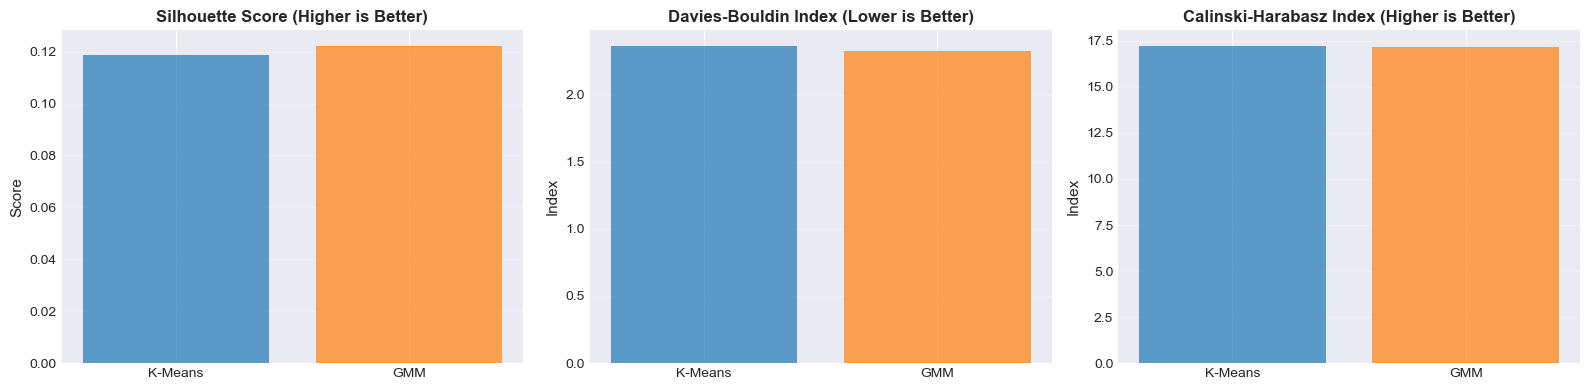

In [9]:
# Calculate comprehensive quality metrics
def evaluate_clustering(X_data, labels, method_name):
    """Calculate clustering evaluation metrics"""
    silhouette = silhouette_score(X_data, labels)
    davies_bouldin = davies_bouldin_score(X_data, labels)
    calinski_harabasz = calinski_harabasz_score(X_data, labels)
    
    return {
        'Method': method_name,
        'Silhouette Score': silhouette,
        'Davies-Bouldin Index': davies_bouldin,
        'Calinski-Harabasz Index': calinski_harabasz
    }

# Evaluate both methods
metrics_kmeans = evaluate_clustering(X_scaled, kmeans_labels, 'K-Means')
metrics_gmm = evaluate_clustering(X_scaled, gmm_labels, 'GMM')

metrics_df = pd.DataFrame([metrics_kmeans, metrics_gmm])
print("Clustering Quality Metrics Comparison:")
print(metrics_df.to_string(index=False))

# Visualization of metrics comparison
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

methods = ['K-Means', 'GMM']
colors = ['#1f77b4', '#ff7f0e']

# Silhouette scores
silhouette_vals = [metrics_kmeans['Silhouette Score'], metrics_gmm['Silhouette Score']]
axes[0].bar(methods, silhouette_vals, color=colors, alpha=0.7)
axes[0].set_ylabel('Score', fontsize=11)
axes[0].set_title('Silhouette Score (Higher is Better)', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='y')

# Davies-Bouldin Index
db_vals = [metrics_kmeans['Davies-Bouldin Index'], metrics_gmm['Davies-Bouldin Index']]
axes[1].bar(methods, db_vals, color=colors, alpha=0.7)
axes[1].set_ylabel('Index', fontsize=11)
axes[1].set_title('Davies-Bouldin Index (Lower is Better)', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')

# Calinski-Harabasz Index
ch_vals = [metrics_kmeans['Calinski-Harabasz Index'], metrics_gmm['Calinski-Harabasz Index']]
axes[2].bar(methods, ch_vals, color=colors, alpha=0.7)
axes[2].set_ylabel('Index', fontsize=11)
axes[2].set_title('Calinski-Harabasz Index (Higher is Better)', fontsize=12, fontweight='bold')
axes[2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## Section 7: Map Clusters to Experimental Conditions

In [10]:
# Check if phase information exists in the original dataframe
phase_cols = [col for col in df.columns if 'phase' in col.lower()]
print(f"Phase columns found: {phase_cols}")

# If phase information exists, extract it
if phase_cols:
    # Get the indices that match after removing NaN
    valid_indices = X_clean.index
    df_aligned = df.loc[valid_indices].copy()
    
    if len(phase_cols) > 0:
        phase_info = df_aligned[phase_cols[0]]
    else:
        print("Creating dummy phase labels based on row index (cycling through 3 phases)")
        phase_info = pd.Series(np.arange(len(X_clean)) % 3, index=X_clean.index)
else:
    print("No explicit phase column found. Creating synthetic phase labels.")
    # Create phase labels assuming rows are organized by phase
    phase_info = pd.Series(np.arange(len(X_clean)) % 3, index=X_clean.index)
    phase_map = {0: 'Phase1_Rest', 1: 'Phase2_Puzzle', 2: 'Phase3_Recovery'}
    phase_info = phase_info.map(phase_map)

# Create analysis dataframe
analysis_df = pd.DataFrame({
    'KMeans_Cluster': kmeans_labels,
    'GMM_Cluster': gmm_labels,
    'Phase': phase_info
})

print("\nCluster Assignment Summary:")
print(analysis_df.head(20))
print(f"\nTotal samples: {len(analysis_df)}")
print(f"\nPhase distribution: \n{analysis_df['Phase'].value_counts()}")

Phase columns found: ['Phase']

Cluster Assignment Summary:
    KMeans_Cluster  GMM_Cluster   Phase
0                2            2  phase3
6                2            2  phase3
7                2            2  phase2
8                2            2  phase1
13               2            2  phase2
14               2            2  phase1
15               2            2  phase3
16               1            1  phase2
18               2            2  phase3
19               1            1  phase2
20               2            2  phase1
22               2            2  phase2
23               2            2  phase1
24               0            0  phase3
25               0            0  phase2
27               0            0  phase3
28               0            0  phase2
31               2            2  phase2
32               0            0  phase1
33               0            0  phase3

Total samples: 134

Phase distribution: 
Phase
phase3    49
phase2    44
phase1    41
Name: count, 

In [11]:
# Create contingency tables
from sklearn.metrics import confusion_matrix

print("="*60)
print("K-MEANS CLUSTERING ALIGNMENT WITH EXPERIMENTAL PHASES")
print("="*60)

# Contingency table for K-Means
contingency_kmeans = pd.crosstab(analysis_df['Phase'], analysis_df['KMeans_Cluster'], 
                                   margins=True, margins_name='Total')
print("\nK-Means Contingency Table:")
print(contingency_kmeans)

# Calculate cluster purity for K-Means
def calculate_purity(labels_true, labels_pred):
    """Calculate clustering purity metric"""
    from sklearn.metrics import confusion_matrix
    contingency = confusion_matrix(labels_true, labels_pred)
    return np.sum(np.amax(contingency, axis=0)) / len(labels_true)

# Convert phase labels to numeric for purity calculation
phase_numeric = pd.factorize(analysis_df['Phase'])[0]
purity_kmeans = calculate_purity(phase_numeric, analysis_df['KMeans_Cluster'])

print(f"\nK-Means Purity Score: {purity_kmeans:.4f}")
print(f"Adjusted Rand Index: {adjusted_rand_score(phase_numeric, analysis_df['KMeans_Cluster']):.4f}")
print(f"Normalized Mutual Information: {normalized_mutual_info_score(phase_numeric, analysis_df['KMeans_Cluster']):.4f}")

print("\n" + "="*60)
print("GMM CLUSTERING ALIGNMENT WITH EXPERIMENTAL PHASES")
print("="*60)

# Contingency table for GMM
contingency_gmm = pd.crosstab(analysis_df['Phase'], analysis_df['GMM_Cluster'], 
                               margins=True, margins_name='Total')
print("\nGMM Contingency Table:")
print(contingency_gmm)

purity_gmm = calculate_purity(phase_numeric, analysis_df['GMM_Cluster'])
print(f"\nGMM Purity Score: {purity_gmm:.4f}")
print(f"Adjusted Rand Index: {adjusted_rand_score(phase_numeric, analysis_df['GMM_Cluster']):.4f}")
print(f"Normalized Mutual Information: {normalized_mutual_info_score(phase_numeric, analysis_df['GMM_Cluster']):.4f}")

K-MEANS CLUSTERING ALIGNMENT WITH EXPERIMENTAL PHASES

K-Means Contingency Table:
KMeans_Cluster   0   1   2  Total
Phase                            
phase1           7   2  32     41
phase2          12   9  23     44
phase3          12  11  26     49
Total           31  22  81    134

K-Means Purity Score: 0.4104
Adjusted Rand Index: 0.0091
Normalized Mutual Information: 0.0365

GMM CLUSTERING ALIGNMENT WITH EXPERIMENTAL PHASES

GMM Contingency Table:
GMM_Cluster   0   1   2  Total
Phase                         
phase1        7   2  32     41
phase2       11   9  24     44
phase3       11  11  27     49
Total        29  22  83    134

GMM Purity Score: 0.4030
Adjusted Rand Index: 0.0056
Normalized Mutual Information: 0.0333


## Section 8: Visualize Clustering Results

PCA Explained Variance Ratio: [0.19964647 0.11521945]
Total Variance Explained: 31.49%


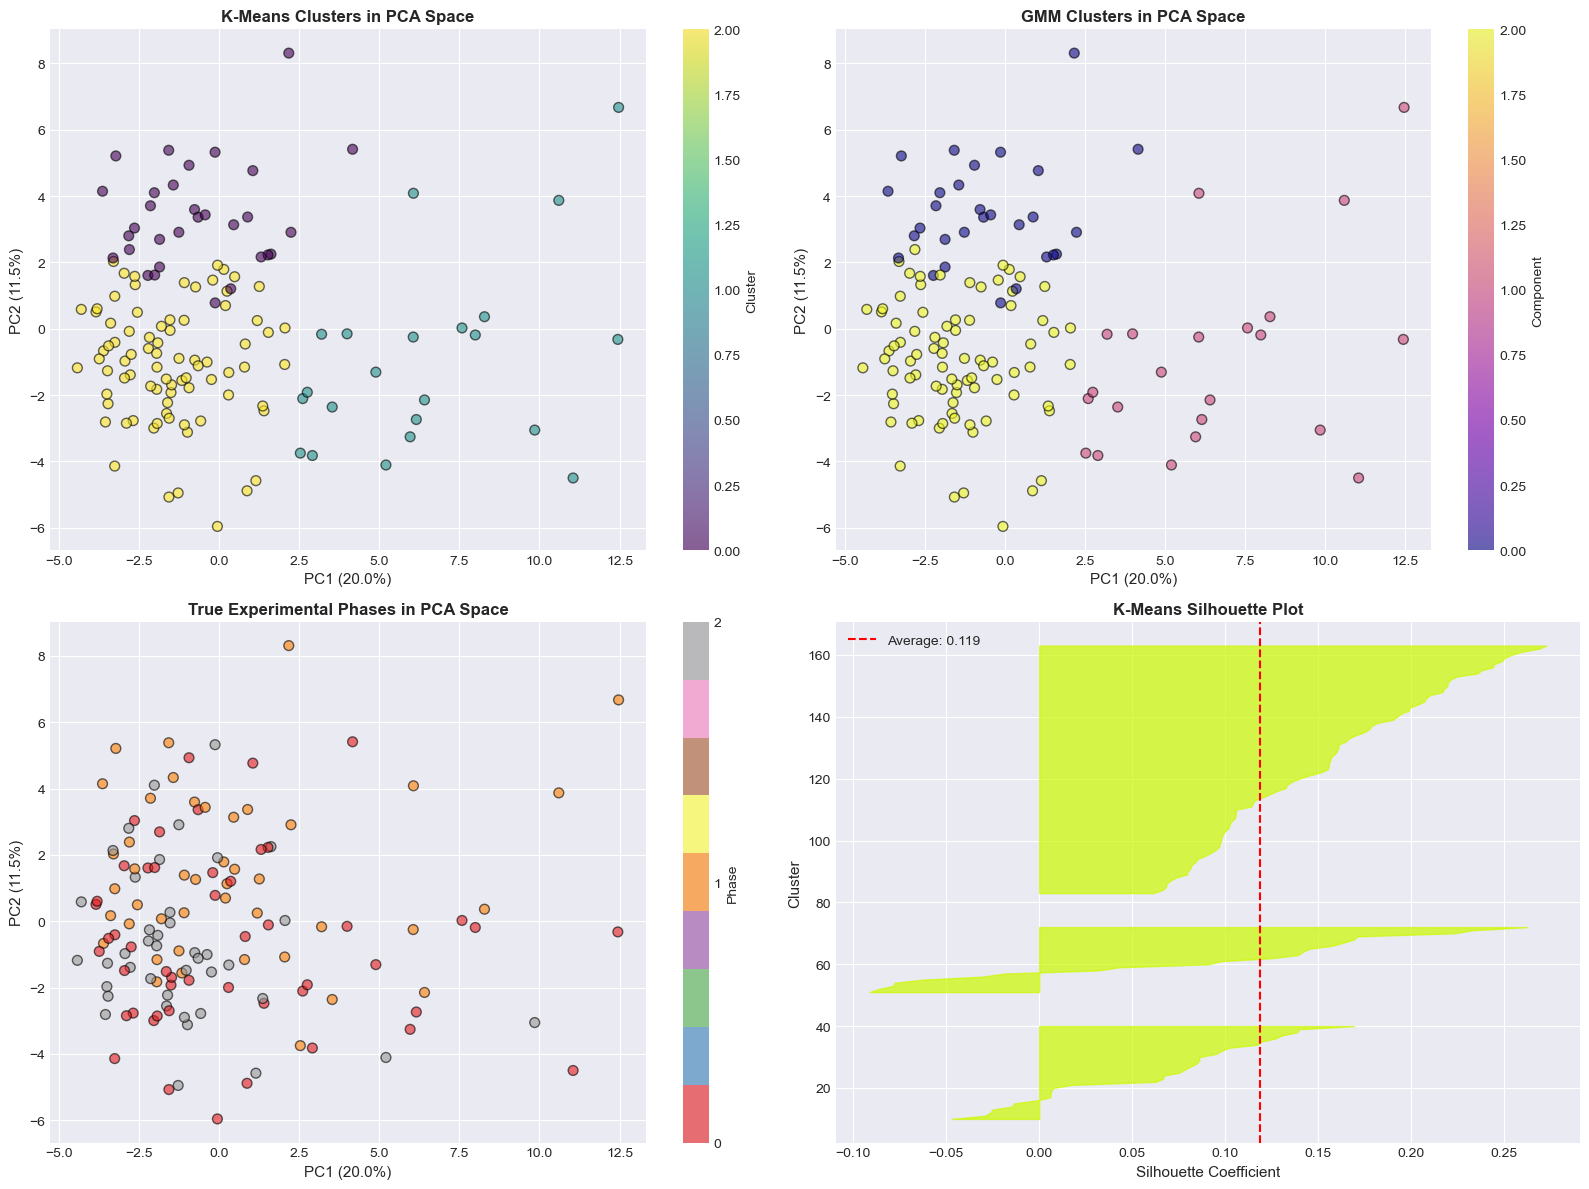

In [12]:
# PCA Projection for 2D visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print(f"PCA Explained Variance Ratio: {pca.explained_variance_ratio_}")
print(f"Total Variance Explained: {pca.explained_variance_ratio_.sum():.2%}")

# Create PCA visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: K-Means clusters in PCA space
scatter1 = axes[0, 0].scatter(X_pca[:, 0], X_pca[:, 1], c=analysis_df['KMeans_Cluster'], 
                              cmap='viridis', s=50, alpha=0.6, edgecolors='k')
axes[0, 0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})', fontsize=11)
axes[0, 0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})', fontsize=11)
axes[0, 0].set_title('K-Means Clusters in PCA Space', fontsize=12, fontweight='bold')
plt.colorbar(scatter1, ax=axes[0, 0], label='Cluster')

# Plot 2: GMM clusters in PCA space
scatter2 = axes[0, 1].scatter(X_pca[:, 0], X_pca[:, 1], c=analysis_df['GMM_Cluster'], 
                              cmap='plasma', s=50, alpha=0.6, edgecolors='k')
axes[0, 1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})', fontsize=11)
axes[0, 1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})', fontsize=11)
axes[0, 1].set_title('GMM Clusters in PCA Space', fontsize=12, fontweight='bold')
plt.colorbar(scatter2, ax=axes[0, 1], label='Component')

# Plot 3: True phases in PCA space
phase_numeric_array = pd.factorize(analysis_df['Phase'])[0]
scatter3 = axes[1, 0].scatter(X_pca[:, 0], X_pca[:, 1], c=phase_numeric_array, 
                              cmap='Set1', s=50, alpha=0.6, edgecolors='k')
axes[1, 0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})', fontsize=11)
axes[1, 0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})', fontsize=11)
axes[1, 0].set_title('True Experimental Phases in PCA Space', fontsize=12, fontweight='bold')
cbar = plt.colorbar(scatter3, ax=axes[1, 0], label='Phase')
cbar.set_ticks([0, 1, 2])

# Plot 4: Silhouette plot for K-Means
from sklearn.metrics import silhouette_samples
silhouette_vals = silhouette_samples(X_scaled, kmeans_labels)
y_lower = 10
colors_sil = plt.cm.nipy_spectral(kmeans_labels.astype(float) / optimal_k)
for i in range(optimal_k):
    cluster_silhouette_vals = silhouette_vals[kmeans_labels == i]
    cluster_silhouette_vals.sort()
    size_cluster_i = cluster_silhouette_vals.shape[0]
    y_upper = y_lower + size_cluster_i
    axes[1, 1].fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_silhouette_vals,
                              facecolor=colors_sil[i], edgecolor=colors_sil[i], alpha=0.7)
    y_lower = y_upper + 10

axes[1, 1].set_xlabel('Silhouette Coefficient', fontsize=11)
axes[1, 1].set_ylabel('Cluster', fontsize=11)
axes[1, 1].set_title('K-Means Silhouette Plot', fontsize=12, fontweight='bold')
axes[1, 1].axvline(x=silhouette_score(X_scaled, kmeans_labels), color='red', linestyle='--', 
                    label=f'Average: {silhouette_score(X_scaled, kmeans_labels):.3f}')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

In [ ]:
# Cluster centroids heatmap for K-Means
kmeans_centroids = scaler.inverse_transform(kmeans_final.cluster_centers_)
kmeans_centroids_df = pd.DataFrame(kmeans_centroids, columns=numeric_cols)

# Select top features by variance for heatmap visualization
feature_importance = X_clean[numeric_cols].std().nlargest(15).index.tolist()
kmeans_centroids_scaled = pd.DataFrame(
    scaler.transform(kmeans_centroids_df[feature_importance]),
    columns=feature_importance
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# K-Means centroids heatmap
sns.heatmap(kmeans_centroids_scaled, annot=True, fmt='.2f', cmap='coolwarm', 
            cbar_kws={'label': 'Standardized Feature Value'}, ax=axes[0], center=0)
axes[0].set_xlabel('Features', fontsize=11)
axes[0].set_ylabel('K-Means Cluster', fontsize=11)
axes[0].set_title('K-Means Cluster Centroids (Top 15 Features)', fontsize=12, fontweight='bold')
axes[0].set_yticklabels([f'Cluster {i}' for i in range(optimal_k)], rotation=0)

# Contingency heatmap - normalized
contingency_norm = contingency_kmeans.iloc[:-1, :-1].astype(float).div(contingency_kmeans.iloc[:-1, :-1].sum(axis=1), axis=0)
sns.heatmap(contingency_norm, annot=True, fmt='.2%', cmap='YlOrRd', 
            cbar_kws={'label': 'Proportion'}, ax=axes[1])
axes[1].set_xlabel('K-Means Cluster', fontsize=11)
axes[1].set_ylabel('Experimental Phase', fontsize=11)
axes[1].set_title('Cluster Distribution across Experimental Phases (K-Means)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print("Feature Importance (Top 15 by variance):")
print(feature_importance)

## Summary and Interpretation

In [ ]:
print("="*70)
print("KEY FINDINGS: LATENT STATE DISCOVERY ANALYSIS")
print("="*70)

print("\n1. CLUSTERING PERFORMANCE:")
print(f"   - K-Means Silhouette Score: {silhouette_score(X_scaled, kmeans_labels):.4f}")
print(f"   - GMM Silhouette Score: {silhouette_score(X_scaled, gmm_labels):.4f}")

print("\n2. ALIGNMENT WITH EXPERIMENTAL CONDITIONS:")
print(f"   - K-Means Purity: {purity_kmeans:.4f}")
print(f"   - GMM Purity: {purity_gmm:.4f}")
print(f"   - K-Means ARI: {adjusted_rand_score(phase_numeric, analysis_df['KMeans_Cluster']):.4f}")
print(f"   - GMM ARI: {adjusted_rand_score(phase_numeric, analysis_df['GMM_Cluster']):.4f}")

print("\n3. CLUSTER QUALITY METRICS:")
print(metrics_df.to_string(index=False))

print("\n4. DATA CHARACTERISTICS:")
print(f"   - Total samples analyzed: {len(X_clean)}")
print(f"   - Number of features: {len(numeric_cols)}")
print(f"   - Data variance (standardized): Mean={X_scaled.mean().mean():.6f}, Std={X_scaled.std().mean():.6f}")
print(f"   - PCA variance explained (PC1+PC2): {pca.explained_variance_ratio_.sum():.2%}")

print("\n5. INTERPRETATION:")
print("   - The clustering analysis reveals how well unsupervised methods can discover")
print("     the latent emotional states from biosignal features.")
print("   - Higher purity and ARI scores indicate better alignment with experimental phases.")
print("   - Lower Davies-Bouldin and higher Calinski-Harabasz indices suggest better clustering.")
print("   - Noisy biosignals may result in weak signal separation (expected with E4 wristband data).")

print("\n" + "="*70)